In [47]:
from IPython.display import Markdown as md

In [48]:
import pandas as pd
import numpy as np
from utils import (
    convert_to_numeric,
    split_dict_columns,
    get_tot_results_compare,
    compare_unique_solved_instances,
    build_markdown_comparison_matrix,
    copy_instances,
    plot_performance_profiles,
    plot_time_histogram,
    query_time,
    SolverResult,
    SOPLEX,
    GLPK,
    QSOPTEX,
)

In [49]:
all_instances = pd.read_csv("../instances.csv").set_index("file")
all_instances

""
file
0003-labyrinth-11-0.smt2
0011-labyrinth-12-0.smt2
0018-labyrinth-11-0.smt2
0028-labyrinth-12-0.smt2
0036-labyrinth-17-0.smt2
...
yPositive-SIscaled75.bpl_Iteration1_Loop_3-pieceTemplate.smt2
yPositive-SIscaled75.bpl_Iteration1_Loop_4-phaseTemplate.smt2
yPositive-SIscaled75.bpl_Iteration1_Loop_4-pieceTemplate.smt2


In [50]:
soplex_i100 = pd.read_csv("../soplex_i100.csv").set_index("file")
soplex_i100

,options::pivots,options::checkModels,build,TheoryEngine::Checks_Full,TheoryEngine::Checks_Last_Call,TheoryEngine::Checks_Standard,TheoryEngine::combineTheoriesCalls,TheoryEngine::combineTheoriesTime,driver::filename,global::totalTime,...,theory::arith::z::approx::refinements,theory::arith::z::arith::relax::calls,theory::arith::z::arith::relax::exhausted,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::feasible::res,theory::arith::z::arith::relax::infeasible,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::arith::relax::other,resultS,timeS
file,,,,,,,,,,,,,,,,,,,,,
sin-problem-7-weak-chunk-0022.smt2,100,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sin-p...,30ms,...,NaN,0,0,0,0,0,0,0,sat,0.030
Braverman-2006CAV-Ex1-int.bpl_Iteration1_Loop_7-phaseTemplate.smt2,100,0,production,0,0,67278,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/Brave...,1062264ms,...,"{ 2: 24, 3: 109, 4: 47 }",180,0,0,126,54,54,0,unsat,1062.264
constraints-cooking12.smt2,100,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/const...,56ms,...,NaN,0,0,0,0,0,0,0,sat,0.056
sc-13.induction3.cvc.smt2,100,0,production,1,1,3249,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sc-13...,247ms,...,NaN,0,0,0,0,0,0,0,sat,0.247
sc-6.induction.cvc.smt2,100,0,production,1,1,470,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sc-6....,69ms,...,NaN,0,0,0,0,0,0,0,sat,0.069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Chua-2-IL-L-chunk-0066.smt2,100,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/Chua-...,44ms,...,NaN,0,0,0,0,0,0,0,sat,0.044
19.smt2,100,0,production,1,1,120,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/19.smt2,80ms,...,NaN,0,0,0,0,0,0,0,sat,0.080
_overflow1.i_3_8_2.bpl_11.smt2,100,0,production,0,0,2558290,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/_over...,6088207ms,...,"{ 1: 1, 11: 1, 2: 1, 3: 12, 4: 35, 5: 17, 6: 5...",105,0,0,70,35,0,0,unsat,6088.207


In [51]:
soplex_i10 = pd.read_csv("../soplex_i10.csv").set_index("file")
soplex_i10

,options::pivots,options::checkModels,build,TheoryEngine::Checks_Full,TheoryEngine::Checks_Last_Call,TheoryEngine::Checks_Standard,TheoryEngine::combineTheoriesCalls,TheoryEngine::combineTheoriesTime,driver::filename,global::totalTime,...,theory::arith::z::approx::refinements,theory::arith::z::arith::relax::calls,theory::arith::z::arith::relax::exhausted,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::feasible::res,theory::arith::z::arith::relax::infeasible,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::arith::relax::other,resultS,timeS
file,,,,,,,,,,,,,,,,,,,,,
sin-problem-7-weak-chunk-0022.smt2,10,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sin-p...,38ms,...,NaN,0,0,0,0,0,0,0,sat,0.038
constraints-cooking12.smt2,10,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/const...,55ms,...,{ 0: 1 },1,0,0,1,0,0,0,sat,0.055
sc-13.induction3.cvc.smt2,10,0,production,1,1,3249,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sc-13...,201ms,...,NaN,0,0,0,0,0,0,0,sat,0.201
sin-problem-7-weak-chunk-0007.smt2,10,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sin-p...,30ms,...,NaN,0,0,0,0,0,0,0,sat,0.030
sin-problem-7-weak-chunk-0095.smt2,10,0,production,0,0,0,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sin-p...,37ms,...,NaN,0,0,0,0,0,0,0,unsat,0.037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sc-23.base.cvc.smt2,10,0,production,0,0,69061,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sc-23...,2255511ms,...,"{ 0: 16, 1: 1127, 2: 31095, 3: 6201, 4: 2392, ...",41573,0,0,1172,40401,40393,0,unsat,2255.511
sin-problem-7-chunk-0006.smt2,10,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sin-p...,37ms,...,NaN,0,0,0,0,0,0,0,sat,0.037
Chua-2-IL-L-chunk-0066.smt2,10,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/Chua-...,45ms,...,NaN,0,0,0,0,0,0,0,sat,0.045


In [52]:
soplex_i200 = pd.read_csv("../soplex_i200.csv").set_index("file")
soplex_i200

,options::pivots,options::checkModels,build,TheoryEngine::Checks_Full,TheoryEngine::Checks_Last_Call,TheoryEngine::Checks_Standard,TheoryEngine::combineTheoriesCalls,TheoryEngine::combineTheoriesTime,driver::filename,global::totalTime,...,theory::arith::z::approx::refinements,theory::arith::z::arith::relax::calls,theory::arith::z::arith::relax::exhausted,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::feasible::res,theory::arith::z::arith::relax::infeasible,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::arith::relax::other,resultS,timeS
file,,,,,,,,,,,,,,,,,,,,,
sin-problem-7-weak-chunk-0022.smt2,200,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sin-p...,33ms,...,NaN,0,0,0,0,0,0,0,sat,0.033
Braverman-2006CAV-Ex1-int.bpl_Iteration1_Loop_7-phaseTemplate.smt2,200,0,production,0,0,87590,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/Brave...,1311068ms,...,"{ 2: 2, 3: 12, 4: 3 }",17,0,0,14,3,3,0,unsat,1311.068
constraints-cooking12.smt2,200,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/const...,40ms,...,NaN,0,0,0,0,0,0,0,sat,0.040
sc-13.induction3.cvc.smt2,200,0,production,1,1,3249,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sc-13...,234ms,...,NaN,0,0,0,0,0,0,0,sat,0.234
sc-6.induction.cvc.smt2,200,0,production,1,1,470,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sc-6....,77ms,...,NaN,0,0,0,0,0,0,0,sat,0.077
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
opt1217--11.smt2,200,0,production,1,1,112059,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/opt12...,1952ms,...,NaN,0,0,0,0,0,0,0,sat,1.952
Chua-2-IL-L-chunk-0066.smt2,200,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/Chua-...,44ms,...,NaN,0,0,0,0,0,0,0,sat,0.044
19.smt2,200,0,production,1,1,120,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/19.smt2,105ms,...,NaN,0,0,0,0,0,0,0,sat,0.105


In [53]:
def sanitize(df: pd.DataFrame):
    for col in df.columns:
        df[col] = df[col].apply(convert_to_numeric)

    df["theory::arith::z::approx::externalSimplexType"] = df["theory::arith::z::approx::externalSimplexType"].astype("category")
    precision_df = df["theory::arith::z::approx::precision"].apply(lambda x: split_dict_columns(x, "precision"))
    refinements = df["theory::arith::z::approx::refinements"].apply(lambda x: split_dict_columns(x, "refinements"))
    return pd.concat([df, precision_df, refinements], axis=1)

soplex_i10 = sanitize(soplex_i10)
soplex_i100 = sanitize(soplex_i100)
soplex_i200 = sanitize(soplex_i200)

In [54]:
# All instances with at least a call to the external simplex should have a value for the external simplex type
def check_external_simplex_calls(df: pd.DataFrame):
    assert len(df[(df["theory::arith::z::arith::relax::calls"] > 0) & (df["theory::arith::z::approx::externalSimplexType"].isna())]) == 0
    assert len(df[df["theory::arith::z::approx::externalSimplexType"].notna()]) == len(df[(df["theory::arith::z::arith::relax::calls"] > 0)])
    assert all(df[df["theory::arith::z::approx::externalSimplexType"].notna()]["theory::arith::z::approx::externalSimplexType"] == SOPLEX)
check_external_simplex_calls(soplex_i10)
check_external_simplex_calls(soplex_i100)
check_external_simplex_calls(soplex_i200)

In [55]:
INTERESTING_COLS = [
    "global::totalTime",
    "theory::arith::z::arith::relax::calls",
    "theory::arith::z::approx::lp::setup::timer",
    "theory::arith::z::approx::lp::timer",
    "theory::arith::z::arith::relax::infeasible::failures",
    "theory::arith::z::approx::precision",
    "theory::arith::z::approx::refinements",
    "theory::arith::attempt::extendedSearch",
]

# Benchmarks

We are using the [SMT-LIB](https://smt-lib.org/benchmarks.shtml) benchmarks for our evaluation.

To be precise, we are using the [QF_LRA](https://smt-lib.org/logics-all.shtml#QF_LRA) theory benchmarks from the [SMT-LIB release 2025 of non-incremental benchmarks](https://zenodo.org/records/16740866).
The set is composed of 1753 instances.
We ran with a timeout of 6 hours (?) and a memory limit of 2GB.
We used the Comet HPC cluster from Newcastle University.
Each node uses an AMD EPYC 9745 @ 2.4 GHz 128-core processor (256 threads), although we only used one core per instance.

### Hardware details

| CPU           | Architecture | Frequency | Turbo frequency | Cores | Memory | L1      | L2        | L3     | Time limit |
| ------------- | ------------ | --------- | --------------- | ----- | ------ | ------- | --------- | ------ | ---------- |
| AMD EPYC 9745 | x86_64       | 2.4 GHz   | 3.7 GHz         | 1     | 2GB    | 6144 KB | 131072 KB | 256 MB | 6 hours    |

In [56]:
# Number of instances solved in total
def get_tot_results(df: pd.DataFrame) -> int:
    assert len(df["options::pivots"].unique()) > 0
    tot = 1753
    table_entries_by_pivot = []
    for pivots in df["options::pivots"].unique():
        sub_df = df[df["options::pivots"] == pivots]
        solved = len(sub_df)
        not_external = len(sub_df[sub_df["theory::arith::z::arith::relax::calls"] == 0])
        external = len(sub_df[sub_df["theory::arith::z::arith::relax::calls"] > 0])
        assert solved == not_external + external
        entry =  f"| **QF_LRA** | {pivots}             | {tot}               | {solved}         | {tot - solved}     | {external}                            | {not_external}                           | 0      |"
        table_entries_by_pivot.append(entry)
        table_rows = "\n".join(table_entries_by_pivot)
    return f"""
### Benchmarks details
    
| Theory     | Rational pivot limit | Number of instances | Solved instances | Unsolved instances | Instances with external simplex calls | Instances without external simplex calls | Errors |
| ---------- | -------------------- | ------------------- | ---------------- | ------------------ | ------------------------------------- | ---------------------------------------- | ------ |
{table_rows}
"""
md(get_tot_results(pd.concat([soplex_i10, soplex_i100, soplex_i200])))


### Benchmarks details

| Theory     | Rational pivot limit | Number of instances | Solved instances | Unsolved instances | Instances with external simplex calls | Instances without external simplex calls | Errors |
| ---------- | -------------------- | ------------------- | ---------------- | ------------------ | ------------------------------------- | ---------------------------------------- | ------ |
| **QF_LRA** | 10             | 1753               | 1111         | 642     | 467                            | 644                           | 0      |
| **QF_LRA** | 100             | 1753               | 1580         | 173     | 208                            | 1372                           | 0      |
| **QF_LRA** | 200             | 1753               | 1595         | 158     | 103                            | 1492                           | 0      |


In [57]:
solver_inputs = [
    SolverResult(soplex_i10, "SoPlex (10 pivots)", "S"),
    SolverResult(soplex_i100, "SoPlex (100 pivots)", "S"),
    SolverResult(soplex_i200, "SoPlex (200 pivots)", "S"),
]

pairwise_only = compare_unique_solved_instances(*solver_inputs)
solver_order = [solver.solver_name for solver in solver_inputs]

md(build_markdown_comparison_matrix(pairwise_only, solver_order))

### Pairwise matrix (instances solved by row solver but not by column solver)
| Solver A \ Solver B | SoPlex (10 pivots) | SoPlex (100 pivots) | SoPlex (200 pivots) |
| --- | --- | --- | --- |
| SoPlex (10 pivots) |  | 10 | 11 |
| SoPlex (100 pivots) | 479 |  | 7 |
| SoPlex (200 pivots) | 495 | 22 |  |

In [58]:
merged = pd.merge(soplex_i10, soplex_i100, left_index=True, right_index=True, suffixes=("_i10", "_i100"))
merged = merged[["global::totalTime_i10", "global::totalTime_i100"]]
merged

,global::totalTime_i10,global::totalTime_i100
file,,
sin-problem-7-weak-chunk-0022.smt2,38,30
constraints-cooking12.smt2,55,56
sc-13.induction3.cvc.smt2,201,247
sin-problem-7-weak-chunk-0007.smt2,30,25
sin-problem-7-weak-chunk-0095.smt2,37,28
...,...,...
sc-23.base.cvc.smt2,2255511,11552
sin-problem-7-chunk-0006.smt2,37,34
Chua-2-IL-L-chunk-0066.smt2,45,44


In [59]:
diffs = pd.DataFrame(merged["global::totalTime_i10"] - merged["global::totalTime_i100"], columns=["time_diff"])
diffs["winner"] = diffs.time_diff.apply(lambda x: "i10" if x < 0 else ("i100" if x > 0 else "tie"))
diffs

min_diff = 10 * 1000
min_diffs = diffs[diffs["time_diff"].abs() > min_diff]
min_diffs["winner"].value_counts()
min_diffs[min_diffs["winner"] == "i10"]

,time_diff,winner
file,,
ecoliMILPglycerolYices3-80000.smt2,-11430,i10
0075-labyrinth-13-0.smt2,-70550,i10
danoint-266.smt2,-188267,i10
wrong_loop.t2.c_Iteration3_Loop_7-phaseTemplate.smt2,-15360,i10
pp08a-5000.smt2,-189819,i10
rand_80_340_1159656267_0.lp.smt2,-38070,i10


In [60]:
external = soplex_i100[soplex_i100["theory::arith::z::arith::relax::calls"] > 0]
external.sort_values("global::totalTime", inplace=True)
external[["global::totalTime", "theory::arith::z::arith::relax::calls", "theory::arith::z::approx::externalSimplexType","resultS"]].head(20)

,global::totalTime,theory::arith::z::arith::relax::calls,theory::arith::z::approx::externalSimplexType,resultS
file,,,,
constraints-cooking13.smt2,54,1,2.0,sat
constraints-cooking19.smt2,55,1,2.0,sat
constraints-cooking20.smt2,60,1,2.0,sat
constraints-cooking16.smt2,60,1,2.0,sat
constraints-cooking14.smt2,63,1,2.0,sat
constraints-tms-2-3-light-30.smt2,67,1,2.0,sat
constraints-tms-2-3-light-20.smt2,70,1,2.0,sat
constraints-cooking21.smt2,70,1,2.0,sat
constraints-tempo-depth-30.smt2,78,1,2.0,sat


In [61]:
# copy_instances(external.head(20))

### Comparison with other solvers

We aim to compare our implementation with other state-of-the-art SMT solvers, such as [Z3](https://github.com/Z3Prover/z3) and [Yices](https://yices.csl.sri.com/), as well as the baseline version of [cvc5](https://cvc5.github.io/), using both the rational simplex implementation and the approximate one via [GLPK](https://www.gnu.org/software/glpk/).

In [62]:
yices = pd.read_csv("../yices.csv").dropna(subset=["resultY"]).set_index("file")
md(get_tot_results_compare(SolverResult(soplex_i100, "SoPlex", "S"), SolverResult(yices, "Yices", "Y")))


#### Yices comparison with SoPlex

| Theory     | Number of instances | Solved instances | Unsolved instances | Not matching results   | In common      | SoPlex only     | Yices only     |
| ---------- | ------------------- | ---------------- | ------------------ | ---------------------- | -------------- | ------------- | -------------- |
| **QF_LRA** | 1753               | 1592         | 161       | 0 | 1479    | 101 | 113 |


In [63]:
z3 = pd.read_csv("../z3.csv").dropna(subset=["resultZ"]).set_index("file")
md(get_tot_results_compare(SolverResult(soplex_i100, "SoPlex", "S"), SolverResult(z3, "Z3", "Z")))


#### Z3 comparison with SoPlex

| Theory     | Number of instances | Solved instances | Unsolved instances | Not matching results   | In common      | SoPlex only     | Z3 only     |
| ---------- | ------------------- | ---------------- | ------------------ | ---------------------- | -------------- | ------------- | -------------- |
| **QF_LRA** | 1753               | 1519         | 234       | 0 | 1448    | 132 | 71 |


In [64]:
cvc5 = pd.read_csv("../cvc5.csv").dropna(subset=["resultC"]).set_index("file")
md(get_tot_results_compare(SolverResult(soplex_i100, "SoPlex", "S"), SolverResult(cvc5, "cvc5", "C")))


#### cvc5 comparison with SoPlex

| Theory     | Number of instances | Solved instances | Unsolved instances | Not matching results   | In common      | SoPlex only     | cvc5 only     |
| ---------- | ------------------- | ---------------- | ------------------ | ---------------------- | -------------- | ------------- | -------------- |
| **QF_LRA** | 1753               | 1632         | 121       | 0 | 1555    | 25 | 77 |


In [65]:
glpk = pd.read_csv("../glpk.csv").dropna(subset=["resultG"]).set_index("file")
md(get_tot_results_compare(SolverResult(soplex_i100, "SoPlex", "S"), SolverResult(glpk, "GLPK", "G")))


#### GLPK comparison with SoPlex

| Theory     | Number of instances | Solved instances | Unsolved instances | Not matching results   | In common      | SoPlex only     | GLPK only     |
| ---------- | ------------------- | ---------------- | ------------------ | ---------------------- | -------------- | ------------- | -------------- |
| **QF_LRA** | 1753               | 1622         | 131       | 0 | 1560    | 20 | 62 |


In [66]:
glpk[glpk["theory::arith::z::arith::relax::calls"] > 0]

,TheoryEngine::Checks_Full,TheoryEngine::Checks_Last_Call,TheoryEngine::Checks_Standard,TheoryEngine::combineTheoriesCalls,TheoryEngine::combineTheoriesTime,driver::filename,global::totalTime,preprocessing::theory-preprocess,sat::clauses_literals,sat::conflicts,...,theory::arith::z::approx::lp::timer,theory::arith::z::arith::relax::calls,theory::arith::z::arith::relax::exhausted,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::feasible::res,theory::arith::z::arith::relax::infeasible,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::arith::relax::other,resultG,timeG
file,,,,,,,,,,,,,,,,,,,,,
constraints-temporal-machine-shop-2-3-A40.smt2,1,1,657,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/const...,204ms,4ms,2788,0,...,12ms,1,0,0,1,0,0,0,sat,0.204
constraints-tempo-matrix7x7.pddl.smt2,1,1,30757,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/const...,762ms,20ms,6656,0,...,29ms,1,0,0,1,0,0,0,sat,0.762
constraints-temporal-machine-shop-2-3-A60.smt2,1,1,2152,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/const...,322ms,12ms,5536,0,...,25ms,1,0,0,1,0,0,0,sat,0.322
janne_complex.t2.c_Iteration3_Lasso_4-pieceTemplate.smt2,0,0,582680,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/janne...,1293758ms,328ms,1866056,22634,...,15ms,3,0,3,3,0,0,0,unsat,1293.758
ecoliMILPglycerolYices3-100000.smt2,1,1,65,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/ecoli...,16760ms,64ms,856,0,...,314ms,13,0,0,7,6,0,0,sat,16.760
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
vpm2-5.smt2,0,0,26285,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/vpm2-...,1702ms,23ms,46905,877,...,1ms,1,0,0,0,1,0,0,unsat,1.702
_sorting_bubblesort_ground.i_4_3_3.bpl_11.smt2,0,0,274484,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/_sort...,691639ms,58ms,2507860,156301,...,1ms,1,0,1,1,0,0,0,unsat,691.639
danoint-50.smt2,0,0,132,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/danoi...,329ms,44ms,15498,8,...,18ms,2,0,0,2,0,0,0,unsat,0.329


In [67]:
assert all(soplex_i100["theory::arith::z::arith::relax::other"] == 0), "Expected no errors in other category"
assert all(soplex_i100["theory::arith::z::arith::relax::feasible::failures"] == 0), "Expected no failures in feasible category"

called = soplex_i100[soplex_i100["theory::arith::z::arith::relax::calls"] > 0][INTERESTING_COLS]
called.sort_values("theory::arith::z::arith::relax::calls", inplace=True)
called

,global::totalTime,theory::arith::z::arith::relax::calls,theory::arith::z::approx::lp::setup::timer,theory::arith::z::approx::lp::timer,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::approx::precision,theory::arith::z::approx::refinements,theory::arith::attempt::extendedSearch
file,,,,,,,,
sas2.t2.c_Iteration5_Lasso_3-pieceTemplate.smt2,273317,1,86,160,0,{ 64: 1 },{ 2: 1 },1
constraints-cooking16.smt2,60,1,1,4,0,{ 64: 1 },{ 0: 1 },0
NoriSharma-2013FSE-Fig8_true-termination.c_Iteration1_Lasso_6-phaseTemplate.smt2,345483,1,114,280,0,{ 64: 1 },{ 2: 1 },1
constraints-tempo-depth-100.smt2,192,1,6,29,0,{ 64: 1 },{ 1: 1 },0
sas2.t2.c_Iteration6_Lasso_3-pieceTemplate.smt2,209616,1,78,536,1,{ 167: 1 },{ 3: 1 },1
...,...,...,...,...,...,...,...,...
fun4.t2.c_Iteration1_Lasso_4-pieceTemplate.smt2,1180785,953,31216,270057,924,"{ 167: 925, 64: 28 }","{ 1: 2, 2: 65, 3: 68, 4: 817, 6: 1 }",953
danoint-266.smt2,438680,1040,11094,51436,0,{ 64: 1040 },"{ 0: 428, 1: 256, 2: 356 }",465
vpm2-13.75.smt2,315144,1303,5840,9342,0,{ 64: 1303 },"{ 0: 877, 1: 56, 2: 370 }",430


In [68]:
called.tail(128).index.tolist()

['p-43.t2.c_Iteration5_Loop_7-phaseTemplate.smt2',
 '_array_single_elem_init.i_4_2_2.bpl_7.smt2',
 'constraints-tms-2-3-light-80.smt2',
 'uart-32.base.cvc.smt2',
 'LeeJonesBen-Amram-2001POPL-Ex5_true-termination.c_Iteration2_Lasso_3-pieceTemplate.smt2',
 'constraints-tms-2-3-light-60.smt2',
 'constraints-tms-2-3-light-70.smt2',
 'constraints-temporal-machine-shop-2-3-A40.smt2',
 'magic.t2.c_Iteration23_Loop_7-phaseTemplate.smt2',
 'constraints-tempo-width-50.smt2',
 'ndes.t2.c_Iteration3_Loop_7-phaseTemplate.smt2',
 'constraints-tempo-matrix7x7.pddl.smt2',
 'broydn.c.i.broydn.pl.t2.fixed.t2.c_Iteration8_Loop_7-phaseTemplate.smt2',
 'constraints-tms-2-3-light-90.smt2',
 'Masse_true-termination.c_Iteration1_Lasso_4-pieceTemplate.smt2',
 'Masse_true-termination.c_Iteration1_Loop_4-pieceTemplate.smt2',
 'clocksynchro_6clocks.main_invar.induct.smt2',
 'min_rf_true-termination.c_Iteration1_Loop_4-pieceTemplate.smt2',
 'pp08a-4000.smt2',
 'ludcmp.t2.c_Iteration8_Loop_6-phaseTemplate.smt2',
 '

In [69]:
assert all(glpk["theory::arith::z::arith::relax::other"] == 0), "Expected no errors in other category"

called = glpk[glpk["theory::arith::z::arith::relax::calls"] > 0][["global::totalTime", "theory::arith::z::arith::relax::feasible::failures", "theory::arith::z::arith::relax::calls","theory::arith::z::approx::lp::timer", "theory::arith::z::arith::relax::infeasible::failures"]]
called.sort_values("theory::arith::z::arith::relax::calls")
called[called["theory::arith::z::arith::relax::feasible::failures"] > 0]

,global::totalTime,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::calls,theory::arith::z::approx::lp::timer,theory::arith::z::arith::relax::infeasible::failures
file,,,,,
janne_complex.t2.c_Iteration3_Lasso_4-pieceTemplate.smt2,1293758ms,3,3,15ms,0
constraints-tempo-depth-100.smt2,485ms,1,1,39ms,0
constraints-tms-2-3-light-60.smt2,202ms,1,1,24ms,0
Lobnya-Boolean-Reordered.bpl_Iteration1_Loop_7-phaseTemplate.smt2,305557ms,7,7,63ms,0
ludcmp.c.i.ludcmp.pl.t2.fixed.t2.c_Iteration9_Loop_7-phaseTemplate.smt2,835286ms,3,3,143ms,0
KroeningSharyginaTsitovichWintersteiger-2010CAV-Fig1_true-termination.c_Iteration1_Lasso_3-pieceTemplate.smt2,557240ms,3,4,170ms,0
GcdNew.bpl_Iteration1_Lasso_7-phaseTemplate.smt2,1003525ms,1,1,23ms,0
eric.t2.c_Iteration1_Lasso_4-pieceTemplate.smt2,2534266ms,1,1,4ms,0
firewire.t2.c_Iteration1_Lasso_3-pieceTemplate.smt2,2184047ms,1,1,30ms,0


In [70]:
soplex_i100.loc["fun4.t2.c_Iteration1_Lasso_4-pieceTemplate.smt2"][INTERESTING_COLS]

global::totalTime                                                                    1180785
theory::arith::z::arith::relax::calls                                                    953
theory::arith::z::approx::lp::setup::timer                                             31216
theory::arith::z::approx::lp::timer                                                   270057
theory::arith::z::arith::relax::infeasible::failures                                     924
theory::arith::z::approx::precision                                     { 167: 925, 64: 28 }
theory::arith::z::approx::refinements                   { 1: 2, 2: 65, 3: 68, 4: 817, 6: 1 }
theory::arith::attempt::extendedSearch                                                   953
Name: fun4.t2.c_Iteration1_Lasso_4-pieceTemplate.smt2, dtype: object

### Cumulative comparisons

Using the [Performance Profile](https://link.springer.com/article/10.1007/s101070100263) approach, we can compare the solvers based on their performance across all instances.

In [71]:
z3_profile = z3.reset_index()[["file", "timeZ", "resultZ"]].set_index("file")
cvc5_profile = cvc5.reset_index()[["file", "timeC", "resultC"]].set_index("file")
yices_profile = yices.reset_index()[["file", "timeY", "resultY"]].set_index("file")
glpk_profile = glpk.reset_index()[["file", "timeG", "resultG"]].set_index("file")
soplex_i10_profile = (
    soplex_i10.reset_index()[["file", "timeS", "resultS"]]
    .rename(columns={"timeS": "timeS10", "resultS": "resultS10"})
    .set_index("file")
)
soplex_i100_profile = (
    soplex_i100.reset_index()[["file", "timeS", "resultS"]]
    .rename(columns={"timeS": "timeS100", "resultS": "resultS100"})
    .set_index("file")
)
soplex_i200_profile = (
    soplex_i200.reset_index()[["file", "timeS", "resultS"]]
    .rename(columns={"timeS": "timeS200", "resultS": "resultS200"})
    .set_index("file")
)
# Get the set of instances where any of the SoPlex variants makes external simplex calls, and filter all profiles to only those instances
external_instances = list(
    set(soplex_i10[soplex_i10["theory::arith::z::arith::relax::calls"] > 0].index)
    | set(soplex_i100[soplex_i100["theory::arith::z::arith::relax::calls"] > 0].index)
    | set(soplex_i200[soplex_i200["theory::arith::z::arith::relax::calls"] > 0].index)
)
cvc5_variants_results = [
    SolverResult(cvc5_profile, "cvc5", "C"),
    SolverResult(glpk_profile, "glpk", "G"),
    SolverResult(soplex_i10_profile, "SoPlex (10 pivots)", "S10"),
    SolverResult(soplex_i100_profile, "SoPlex (100 pivots)", "S100"),
    SolverResult(soplex_i200_profile, "SoPlex (200 pivots)", "S200"),
]
profile_results = (
    *cvc5_variants_results,
    SolverResult(z3_profile, "Z3", "Z"),
    SolverResult(yices_profile, "yices", "Y"),
)
external_cvc5_variants__results = [
    SolverResult(cvc5_profile.loc[np.intersect1d(cvc5_profile.index, external_instances)], "cvc5", "C"),
    SolverResult(glpk_profile.loc[np.intersect1d(glpk_profile.index, external_instances)], "glpk", "G"),
    SolverResult(soplex_i10_profile.loc[np.intersect1d(soplex_i10_profile.index, external_instances)], "SoPlex (10 pivots)", "S10"),
    SolverResult(soplex_i100_profile.loc[np.intersect1d(soplex_i100_profile.index, external_instances)], "SoPlex (100 pivots)", "S100"),
    SolverResult(soplex_i200_profile.loc[np.intersect1d(soplex_i200_profile.index, external_instances)], "SoPlex (200 pivots)", "S200"),
]
external_profile_results = (
    *external_cvc5_variants__results,
    SolverResult(z3_profile.loc[np.intersect1d(z3_profile.index, external_instances)], "Z3", "Z"),
    SolverResult(yices_profile.loc[np.intersect1d(yices_profile.index, external_instances)], "yices", "Y"),
)

In [72]:
unsolved_yices = set(all_instances.loc[~all_instances.index.isin(yices_profile.index)].index)
unsolved_yices

{'0206-labyrinth-20-0.smt2',
 'BradleyMannaSipma-2005ICALP-Fig1_true-termination.c_Iteration1_Lasso_4-pieceTemplate.smt2',
 'BradleyMannaSipma-2005ICALP-Fig1_true-termination.c_Iteration1_Lasso_5-phaseTemplate.smt2',
 'BradleyMannaSipma-2005ICALP-Fig1_true-termination.c_Iteration1_Lasso_6-phaseTemplate.smt2',
 'BradleyMannaSipma-2005ICALP-Fig1_true-termination.c_Iteration1_Lasso_7-phaseTemplate.smt2',
 'Braverman-2006CAV-Ex1-int.bpl_Iteration1_Lasso_4-pieceTemplate.smt2',
 'Braverman-2006CAV-Ex1-int.bpl_Iteration1_Lasso_5-phaseTemplate.smt2',
 'Braverman-2006CAV-Ex1-int.bpl_Iteration1_Lasso_6-phaseTemplate.smt2',
 'Braverman-2006CAV-Ex1-int.bpl_Iteration1_Lasso_7-phaseTemplate.smt2',
 'Braverman-2006CAV-Ex1-int.bpl_Iteration1_Loop_4-pieceTemplate.smt2',
 'Braverman-2006CAV-Ex1-int.bpl_Iteration1_Loop_5-phaseTemplate.smt2',
 'Braverman-2006CAV-Ex1-int.bpl_Iteration1_Loop_6-phaseTemplate.smt2',
 'Braverman-2006CAV-Ex1-int.bpl_Iteration1_Loop_7-phaseTemplate.smt2',
 'KroeningSharyginaTsit

In [73]:
# Instances that have not been solved by at least one solver (i.e. instances that are not in the dataframe of at least one of the solvers)
unsolved = set.union(*[set(all_instances.loc[~all_instances.index.isin(result.dataframe.index)].index) for result in profile_results])
"-----".join(f"/nobackup/proj/comet_lfplpsmf/QF_LRA/all/{u}" for u in unsolved)

'/nobackup/proj/comet_lfplpsmf/QF_LRA/all/joey_false-termination.c_Iteration1_Loop_7-phaseTemplate.smt2-----/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sas2.t2.c_Iteration1_Lasso_7-phaseTemplate.smt2-----/nobackup/proj/comet_lfplpsmf/QF_LRA/all/p-0-bucket_s13.smt2-----/nobackup/proj/comet_lfplpsmf/QF_LRA/all/p7-driverlogNumeric_s7.smt2-----/nobackup/proj/comet_lfplpsmf/QF_LRA/all/constraints-cooking07.smt2-----/nobackup/proj/comet_lfplpsmf/QF_LRA/all/fs_frame_gap.base.smt2-----/nobackup/proj/comet_lfplpsmf/QF_LRA/all/joey_false-termination.c_Iteration2_Loop_7-phaseTemplate.smt2-----/nobackup/proj/comet_lfplpsmf/QF_LRA/all/_avg60.i_5_5_4.bpl_5.smt2-----/nobackup/proj/comet_lfplpsmf/QF_LRA/all/fir.t2.c_Iteration4_Loop_6-phaseTemplate.smt2-----/nobackup/proj/comet_lfplpsmf/QF_LRA/all/simple-scaled100.bpl_Iteration1_Lasso_3-pieceTemplate.smt2-----/nobackup/proj/comet_lfplpsmf/QF_LRA/all/brp_withassume.t2.c_Iteration8_Loop_2-pieceTemplate.smt2-----/nobackup/proj/comet_lfplpsmf/QF_LRA/all/0067-

In [74]:
len(unsolved)

684

(<Axes: title={'center': 'Time histogram for all solvers'}, xlabel='Time (ms)', ylabel='Number of instances'>,
 array([    0.     ,  1017.24455,  2034.4891 ,  3051.73365,  4068.9782 ,
         5086.22275,  6103.4673 ,  7120.71185,  8137.9564 ,  9155.20095,
        10172.4455 , 11189.69005, 12206.9346 , 13224.17915, 14241.4237 ,
        15258.66825, 16275.9128 , 17293.15735, 18310.4019 , 19327.64645,
        20344.891  ]))

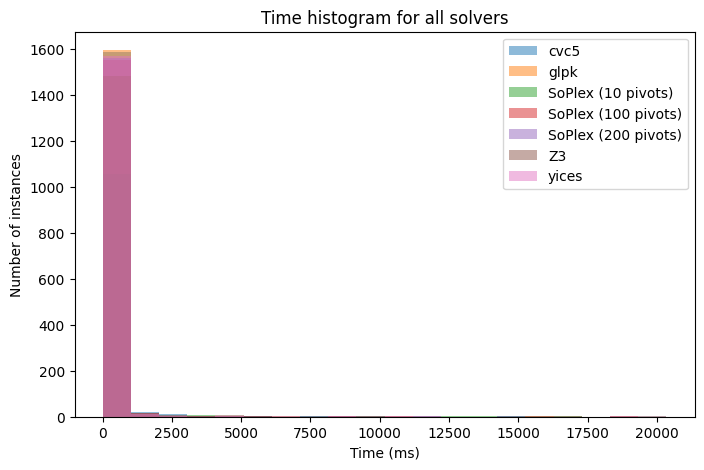

In [75]:
plot_time_histogram(*profile_results, title="Time histogram for all solvers", fixed_min_bin=0)

In [76]:
len(set(soplex_i100[soplex_i100["theory::arith::z::arith::relax::calls"] > 0].index)
    | set(soplex_i200[soplex_i200["theory::arith::z::arith::relax::calls"] > 0].index))

221

In [77]:
query_time(*profile_results, instances=("0028-labyrinth-12-0.smt2", "0075-labyrinth-13-0.smt2"))

,cvc5,glpk,SoPlex (10 pivots),SoPlex (100 pivots),SoPlex (200 pivots),Z3,yices
0028-labyrinth-12-0.smt2,36.900,29.747,24.467,29.919,35.621,3.57,2.888
0075-labyrinth-13-0.smt2,122.582,106.315,36.765,107.315,119.387,8.40,321.847


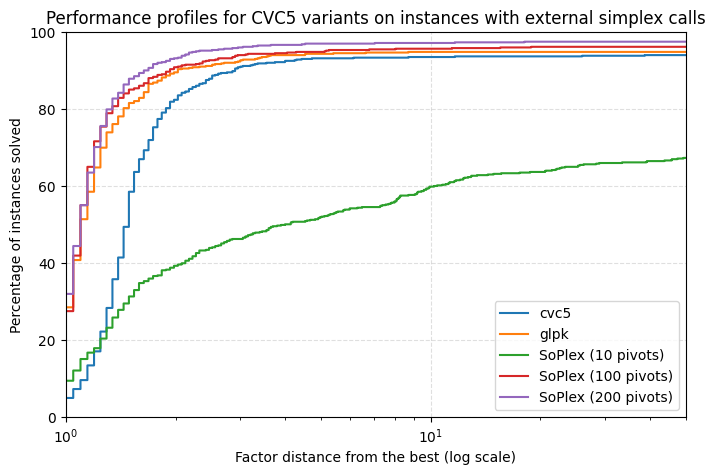

In [79]:
ax, fig = plot_performance_profiles(
    *external_cvc5_variants__results,
    accepted_results=["sat", "unsat"],
    result_cols="result",
    metric_cols="time",
    max_tau=50,
    # metric_add=0.001,
    title="Performance profiles for CVC5 variants on instances with external simplex calls",
)
# Save the figure for latex paper
ax.get_figure().savefig("cvc5_external_simplex_calls.pdf", bbox_inches="tight")

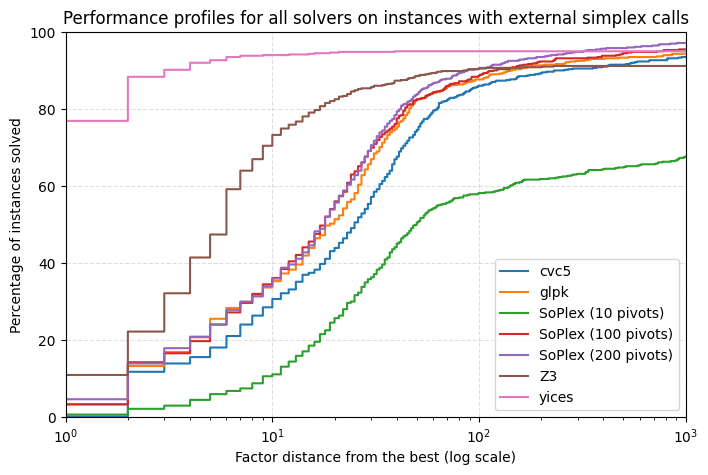

In [80]:
ax, fig = plot_performance_profiles(
    *external_profile_results,
    accepted_results=["sat", "unsat"],
    result_cols="result",
    metric_cols="time",
    max_tau=1000,
    metric_add=0.001,
    title="Performance profiles for all solvers on instances with external simplex calls",
)
ax.get_figure().savefig("all_external_simplex_calls.pdf", bbox_inches="tight")

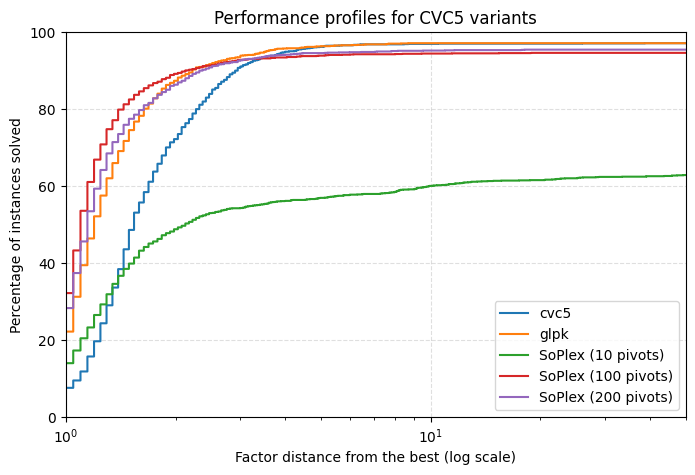

In [ ]:
ax, fig = plot_performance_profiles(
    *cvc5_variants_results,
    accepted_results=["sat", "unsat"],
    result_cols="result",
    metric_cols="time",
    max_tau=50,
    metric_add=0.001,
    title="Performance profiles for CVC5 variants",
)

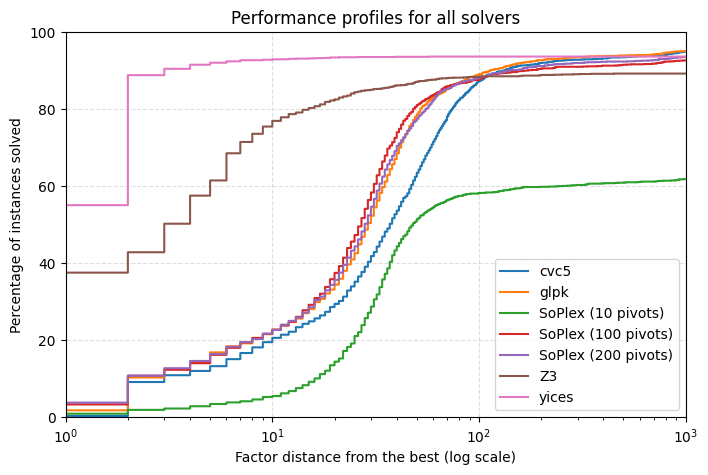

In [ ]:
ax, fig = plot_performance_profiles(
    *profile_results,
    accepted_results=["sat", "unsat"],
    result_cols="result",
    metric_cols="time",
    max_tau=1000,
    metric_add=0.001,
    title="Performance profiles for all solvers",
)